# Chapter 10: 3D Reconstruction of Cameras and Structure

Source orientation: printed pages 262-278; PDF pages 280-296. The source pages were used for topic order, notation, and theorem coverage; the explanations, data, code, and figures below are original.

This chapter answers a precise question: if two uncalibrated images contain matching points, what cameras and 3D points can be recovered, and which remaining ambiguity is unavoidable?

## Chapter Goal

Build a complete two-view reconstruction loop on synthetic data: estimate a fundamental matrix from point correspondences, retrieve one compatible camera pair, triangulate structure, and verify that a 3D projective transformation changes the recovered coordinates without changing either image. Then add the two extra geometric objects used in stratified reconstruction: the plane at infinity for an affine upgrade and the absolute conic or image of the absolute conic for a metric upgrade.

## Computational Translation Guide

| Book object | Computational object in this notebook | What must be checked |
| --- | --- | --- |
| Image correspondence $x_i \leftrightarrow x'_i$ | two arrays of homogeneous or inhomogeneous image points | $x_i'^T F x_i \approx 0$ |
| Fundamental matrix $F$ | rank-2 `3 x 3` matrix estimated from correspondences | rank, scale-insensitive residuals |
| Camera retrieval from $F$ | canonical cameras $P=[I|0]$ and $P'=[[e']_\times F|e']$ | both cameras reproduce the same image points after triangulation |
| Triangulated structure $X_i$ | SVD nullspaces of the two projection equations | reprojection error in both views |
| Projective ambiguity | $X_i \mapsto H X_i$, $P \mapsto P H^{-1}$ | image points are unchanged although 3D angles and parallelism may change |
| Affine upgrade | identify a plane $\pi_\infty$ and apply $H_\pi=\begin{bmatrix}I&0\\ \pi^T\end{bmatrix}$ | $H_\pi^{-T}\pi_\infty=(0,0,0,1)^T$ and parallel directions return |
| Metric upgrade | use the IAC $\omega$ and Cholesky factor $A A^T=(M^T\omega M)^{-1}$ | right-angle and distance-ratio checks become Euclidean again |
| Direct upgrade with ground control | estimate a `4 x 4` homography from known 3D control points | held-out reconstructed points align with the Euclidean scene |

## Library Routing

| Concept | Representation | Library route | Why this route fits |
| --- | --- | --- | --- |
| Two-view algebra and triangulation | SVD systems, homogeneous coordinates | NumPy plus the course `utils.epipolar` and `utils.cameras` helpers | exposes the exact matrices used by the reconstruction theorem |
| Fundamental matrix cross-check | rank-2 two-view relation | OpenCV `cv2.findFundamentalMat`, compared with the course normalized eight-point routine | this is the computer-vision library route for image correspondences, with NumPy checks kept visible |
| Camera/structure and projective ambiguity | rotatable 3D scene | Plotly standalone HTML | the learner can inspect how 3D coordinates change while image measurements do not |
| Triangulation, stratification, and ground-control diagnostics | durable annotated diagrams | Matplotlib | static figures are better for labeled rays, residual arrows, and side-by-side upgrade comparisons |
| Reconstruction theorem proof scaffold | dependency graph | NetworkX plus Matplotlib | the theorem is a chain of implications with one baseline exception |
| Plane-at-infinity identity | exact block-matrix check | SymPy | verifies the affine-upgrade formula without floating-point tolerance |

## Route Through The Chapter

1. Make a small Euclidean scene and two calibrated cameras only so that the experiment has ground truth.
2. Throw away the calibration and recover a projective reconstruction from image correspondences.
3. Verify the projective reconstruction theorem numerically: transformed cameras and transformed points leave the images fixed.
4. Upgrade the same projective coordinates first to affine by locating $\pi_\infty$, then to metric by using the IAC.
5. Compare this stratified route with a direct upgrade from five ground-control points.

In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-10"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"BOOK_ROOT = {BOOK_ROOT}")
print(f"ARTIFACT_ROOT = {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

BOOK_ROOT = Multiple-View-Geometry-in-Computer-Vision
ARTIFACT_ROOT = artifacts/chapter-10


In [2]:
import json
import math

import cv2
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from plotly.subplots import make_subplots

from utils.artifacts import (
    assert_artifacts,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)
from utils.cameras import camera_center, camera_matrix, look_at_rotation, make_calibration, project_points, skew
from utils.epipolar import eight_point, enforce_rank2, fundamental_from_cameras, linear_triangulate, sampson_errors
from utils.projective import dehomogenize, homogenize

np.set_printoptions(precision=5, suppress=True)
artifact_paths = []
check_data = {"source_span": "printed pages 262-278; PDF pages 280-296"}

## Synthetic Two-View Lab

The chapter is about what can be inferred from correspondences, not about a particular house or camera rig. The synthetic scene below gives us exact ground truth so that every ambiguity can be measured. After the image points are produced, the reconstruction code treats them as uncalibrated correspondences.

In [3]:
def house_scene():
    points = np.array(
        [
            [-1.2, -0.7, 3.2], [1.2, -0.7, 3.2], [1.2, 0.7, 3.2], [-1.2, 0.7, 3.2],
            [-1.2, -0.7, 5.0], [1.2, -0.7, 5.0], [1.2, 0.7, 5.0], [-1.2, 0.7, 5.0],
            [0.0, 1.35, 3.2], [0.0, 1.35, 5.0],
            [-0.45, -0.25, 3.19], [0.45, -0.25, 3.19], [0.45, 0.35, 3.19], [-0.45, 0.35, 3.19],
            [-0.9, -0.72, 4.35], [-0.2, -0.72, 4.35], [0.7, -0.72, 4.35],
        ],
        dtype=float,
    )
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7),
        (3, 8), (8, 2), (7, 9), (9, 6), (8, 9),
        (10, 11), (11, 12), (12, 13), (13, 10),
        (14, 15), (15, 16),
    ]
    return points, edges


def camera_pair_from_fundamental(F):
    _, _, vt = np.linalg.svd(F.T)
    e2 = vt[-1]
    e2 = e2 / np.linalg.norm(e2)
    return np.hstack([skew(e2) @ F, e2.reshape(3, 1)])


def compare_up_to_scale(A, B):
    a = np.asarray(A, dtype=float).ravel()
    b = np.asarray(B, dtype=float).ravel()
    scale = float(np.dot(a, b) / np.dot(b, b))
    return float(np.linalg.norm(a - scale * b) / np.linalg.norm(a)), scale


def apply_homography_3d(H, points):
    mapped = (np.asarray(H, dtype=float) @ homogenize(points).T).T
    return dehomogenize(mapped)


def estimate_projective_homography_3d(source_points, target_points):
    source = homogenize(source_points)
    target = homogenize(target_points)
    rows = []
    for X, Y in zip(source, target):
        for j in range(3):
            row = np.zeros(16)
            row[4 * j : 4 * (j + 1)] = -Y[3] * X
            row[12:16] = Y[j] * X
            rows.append(row)
    _, _, vt = np.linalg.svd(np.asarray(rows))
    H = vt[-1].reshape(4, 4)
    scale = H[-1, -1] if abs(H[-1, -1]) > 1e-12 else np.linalg.norm(H)
    return H / scale


def draw_image_edges(ax, image_points, edges, *, color, label=None, marker="o"):
    ax.scatter(image_points[:, 0], image_points[:, 1], s=28, color=color, label=label, zorder=3, marker=marker)
    for i, j in edges:
        ax.plot([image_points[i, 0], image_points[j, 0]], [image_points[i, 1], image_points[j, 1]], color=color, alpha=0.55, linewidth=1.1)
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.18)


def draw_structure_3d(ax, points, edges, *, color, title, highlight=True):
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color=color, s=20, depthshade=False)
    for i, j in edges:
        lw = 2.5 if highlight and (i, j) in {(0, 1), (3, 2), (0, 3)} else 1.0
        alpha = 0.95 if lw > 1.0 else 0.45
        ax.plot([points[i, 0], points[j, 0]], [points[i, 1], points[j, 1]], [points[i, 2], points[j, 2]], color=color, alpha=alpha, linewidth=lw)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")


def set_equal_3d(ax, point_sets):
    pts = np.vstack(point_sets)
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.55 * max(maxs - mins)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


def triangulation_matrix(P, P_prime, x, x_prime):
    u, v = x[:2]
    up, vp = x_prime[:2]
    return np.vstack([u * P[2] - P[0], v * P[2] - P[1], up * P_prime[2] - P_prime[0], vp * P_prime[2] - P_prime[1]])


def direction_cosine(points, edge_a, edge_b):
    i, j = edge_a
    k, l = edge_b
    u = points[j] - points[i]
    v = points[l] - points[k]
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))

In [4]:
scene_points, scene_edges = house_scene()
K = make_calibration(880.0, 860.0, 320.0, 240.0)
center_1 = np.array([-2.4, 0.55, 0.35])
center_2 = np.array([2.1, 0.70, 0.10])
target = np.array([0.0, 0.15, 4.2])
P1 = camera_matrix(K, look_at_rotation(center_1, target), center_1)
P2 = camera_matrix(K, look_at_rotation(center_2, target), center_2)
image_1 = project_points(P1, scene_points)
image_2 = project_points(P2, scene_points)

F_est = eight_point(image_1, image_2)
F_true = fundamental_from_cameras(P1, P2)
F_cv_raw, cv_mask = cv2.findFundamentalMat(image_1.astype(np.float64), image_2.astype(np.float64), cv2.FM_8POINT)
F_cv = enforce_rank2(F_cv_raw) if F_cv_raw is not None else F_est.copy()

P1_canonical = np.hstack([np.eye(3), np.zeros((3, 1))])
P2_canonical = camera_pair_from_fundamental(F_est)
projective_points = linear_triangulate(P1_canonical, P2_canonical, image_1, image_2)
reprojected_1 = project_points(P1_canonical, projective_points)
reprojected_2 = project_points(P2_canonical, projective_points)

fundamental_scale_error, fundamental_scale = compare_up_to_scale(F_est, F_true)
check_data.update(
    {
        "point_count": int(len(scene_points)),
        "eight_point_rank": int(np.linalg.matrix_rank(F_est, tol=1e-10)),
        "eight_point_sampson_max": float(np.max(sampson_errors(F_est, image_1, image_2))),
        "opencv_sampson_max": float(np.max(sampson_errors(F_cv, image_1, image_2))),
        "fundamental_scale_relative_error": fundamental_scale_error,
        "canonical_reprojection_max_px": float(max(np.max(np.linalg.norm(reprojected_1 - image_1, axis=1)), np.max(np.linalg.norm(reprojected_2 - image_2, axis=1)))),
    }
)
check_data

{'source_span': 'printed pages 262-278; PDF pages 280-296',
 'point_count': 17,
 'eight_point_rank': 2,
 'eight_point_sampson_max': 8.173176472886726e-21,
 'opencv_sampson_max': 7.685545429893881e-11,
 'fundamental_scale_relative_error': 2.4891051659660506e-16,
 'canonical_reprojection_max_px': 1.2517206079572008e-10}

## Triangulation And The Baseline Exception

When $x'^T F x=0$, the two back-projected rays lie in one epipolar plane. Away from the baseline, their intersection is a single 3D point. A point on the baseline is different: it projects to the epipoles, so the two rays coincide and the triangulation equations lose another rank.

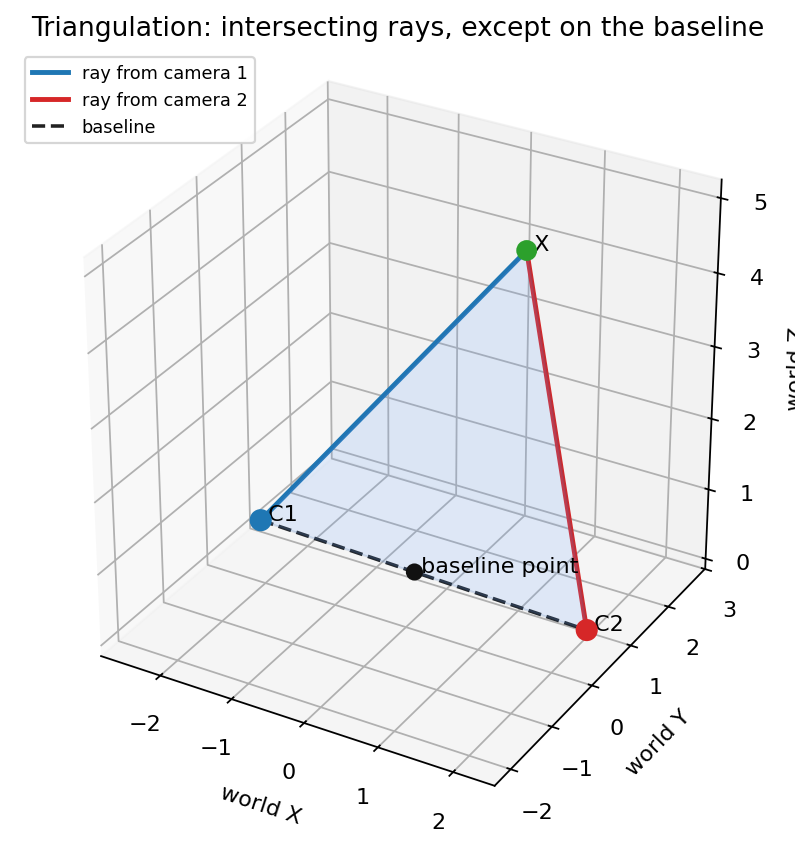

{'regular_triangulation_rank': 3,
 'baseline_triangulation_rank': 2,
 'baseline_small_singular_values': [4.3195058609918435e-13,
  2.0459675097407257e-13]}

In [5]:
sample_index = 6
C1 = camera_center(P1)[:3]
C2 = camera_center(P2)[:3]
X = scene_points[sample_index]
baseline_point = C1 + 0.48 * (C2 - C1)
baseline_image_1 = project_points(P1, baseline_point.reshape(1, 3))[0]
baseline_image_2 = project_points(P2, baseline_point.reshape(1, 3))[0]
regular_A = triangulation_matrix(P1, P2, image_1[sample_index], image_2[sample_index])
baseline_A = triangulation_matrix(P1, P2, baseline_image_1, baseline_image_2)
regular_rank = int(np.linalg.matrix_rank(regular_A, tol=1e-7))
baseline_rank = int(np.linalg.matrix_rank(baseline_A, tol=1e-7))

fig = plt.figure(figsize=(9.5, 6.2))
ax = fig.add_subplot(111, projection="3d")
plane = np.array([C1, C2, X])
ax.add_collection3d(Poly3DCollection([plane], alpha=0.16, facecolor="#66a3ff", edgecolor="#2f5f9f", linewidth=1.0))
ax.plot([C1[0], X[0]], [C1[1], X[1]], [C1[2], X[2]], color="#1f77b4", linewidth=2.2, label="ray from camera 1")
ax.plot([C2[0], X[0]], [C2[1], X[1]], [C2[2], X[2]], color="#d62728", linewidth=2.2, label="ray from camera 2")
ax.plot([C1[0], C2[0]], [C1[1], C2[1]], [C1[2], C2[2]], color="#222222", linestyle="--", linewidth=1.6, label="baseline")
ax.scatter([C1[0], C2[0], X[0], baseline_point[0]], [C1[1], C2[1], X[1], baseline_point[1]], [C1[2], C2[2], X[2], baseline_point[2]], color=["#1f77b4", "#d62728", "#2ca02c", "#111111"], s=[80, 80, 70, 45], depthshade=False)
ax.text(*C1, " C1")
ax.text(*C2, " C2")
ax.text(*X, " X")
ax.text(*baseline_point, " baseline point")
ax.set_title("Triangulation: intersecting rays, except on the baseline")
ax.set_xlabel("world X")
ax.set_ylabel("world Y")
ax.set_zlabel("world Z")
set_equal_3d(ax, [np.vstack([scene_points, C1, C2, baseline_point])])
ax.legend(loc="upper left", fontsize=8)
triangulation_path = save_matplotlib(fig, TOPIC, "figures", "triangulation-epipolar-rays.png")
plt.close(fig)
artifact_paths.append(triangulation_path)

check_data.update(
    {
        "regular_triangulation_rank": regular_rank,
        "baseline_triangulation_rank": baseline_rank,
        "baseline_small_singular_values": [float(v) for v in np.linalg.svd(baseline_A, compute_uv=False)[-2:]],
    }
)
display_artifact(triangulation_path, width=860)
{key: check_data[key] for key in ["regular_triangulation_rank", "baseline_triangulation_rank", "baseline_small_singular_values"]}

## Projective Reconstruction Theorem As A Dependency Graph

The theorem has two parts. First, if the correspondences determine a unique $F$, then any two camera pairs compatible with that $F$ differ by one 3D projective transformation. Second, the corresponding 3D points must also be mapped by the same transformation unless the image point is an epipole in both views, which is exactly the baseline exception.

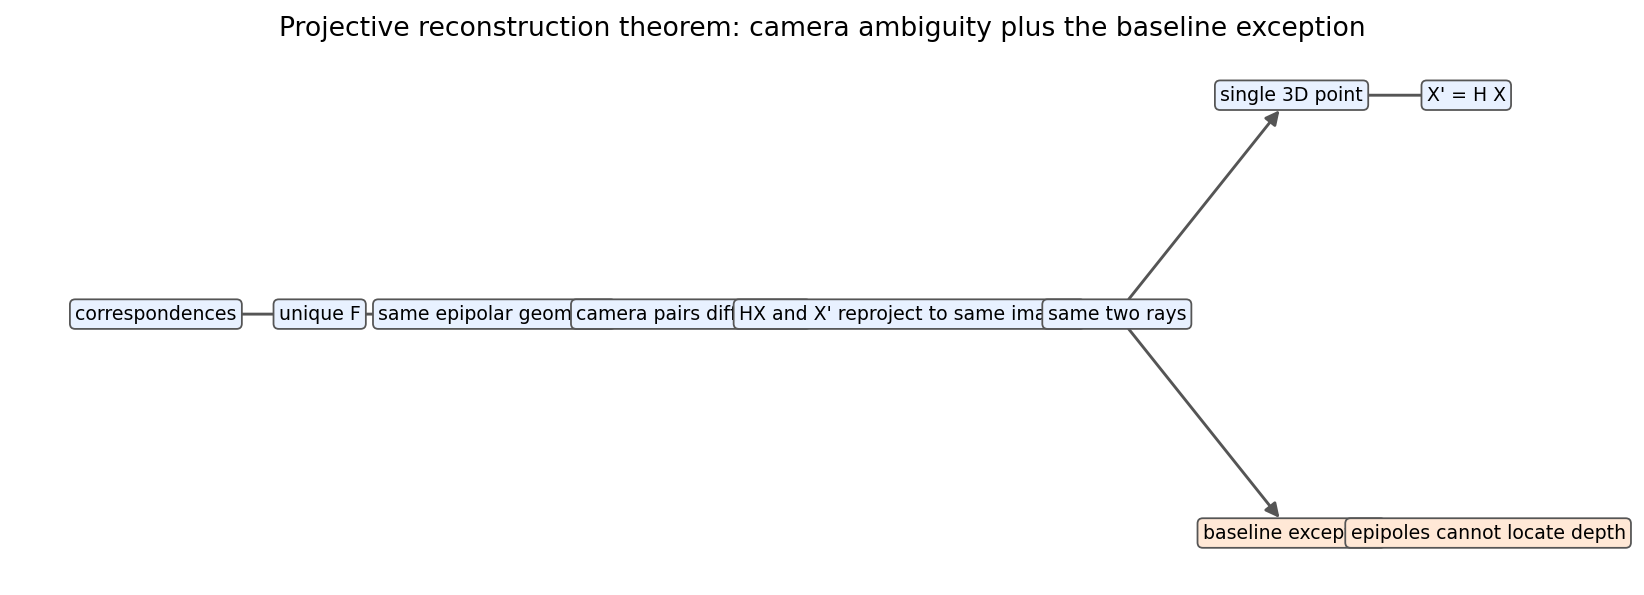

True

In [6]:
proof_graph = nx.DiGraph()
proof_edges = [
    ("correspondences", "unique F"),
    ("unique F", "same epipolar geometry"),
    ("same epipolar geometry", "camera pairs differ by H"),
    ("camera pairs differ by H", "HX and X' reproject to same images"),
    ("HX and X' reproject to same images", "same two rays"),
    ("same two rays", "single 3D point"),
    ("same two rays", "baseline exception"),
    ("single 3D point", "X' = H X"),
    ("baseline exception", "epipoles cannot locate depth"),
]
proof_graph.add_edges_from(proof_edges)
positions = {
    "correspondences": (0, 3),
    "unique F": (1.5, 3),
    "same epipolar geometry": (3.1, 3),
    "camera pairs differ by H": (4.9, 3),
    "HX and X' reproject to same images": (6.9, 3),
    "same two rays": (8.8, 3),
    "single 3D point": (10.4, 3.65),
    "baseline exception": (10.4, 2.35),
    "X' = H X": (12.0, 3.65),
    "epipoles cannot locate depth": (12.2, 2.35),
}
fig, ax = plt.subplots(figsize=(13, 4.3))
nx.draw_networkx_edges(proof_graph, positions, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=13, width=1.3, edge_color="#555555")
for node, (x, y) in positions.items():
    color = "#ffe8d6" if "exception" in node or "epipoles" in node else "#e8f1ff"
    ax.text(x, y, node, ha="center", va="center", fontsize=8.5, bbox=dict(boxstyle="round,pad=0.28", fc=color, ec="#555555", lw=0.8))
ax.set_title("Projective reconstruction theorem: camera ambiguity plus the baseline exception")
ax.set_axis_off()
proof_path = save_matplotlib(fig, TOPIC, "figures", "projective-reconstruction-theorem-dependency.png")
plt.close(fig)
artifact_paths.append(proof_path)
check_data["theorem_graph_is_dag"] = bool(nx.is_directed_acyclic_graph(proof_graph))
display_artifact(proof_path, width=900)
check_data["theorem_graph_is_dag"]

## Reprojection Invariance Of The Canonical Reconstruction

The canonical pair $P=[I|0]$, $P'=[[e']_\times F|e']$ is not the original Euclidean camera rig. It is just one projective coordinate frame compatible with the measured correspondences. The residual arrows below are intentionally tiny: the recovered 3D points are strange coordinates, but their projections agree with the two images.

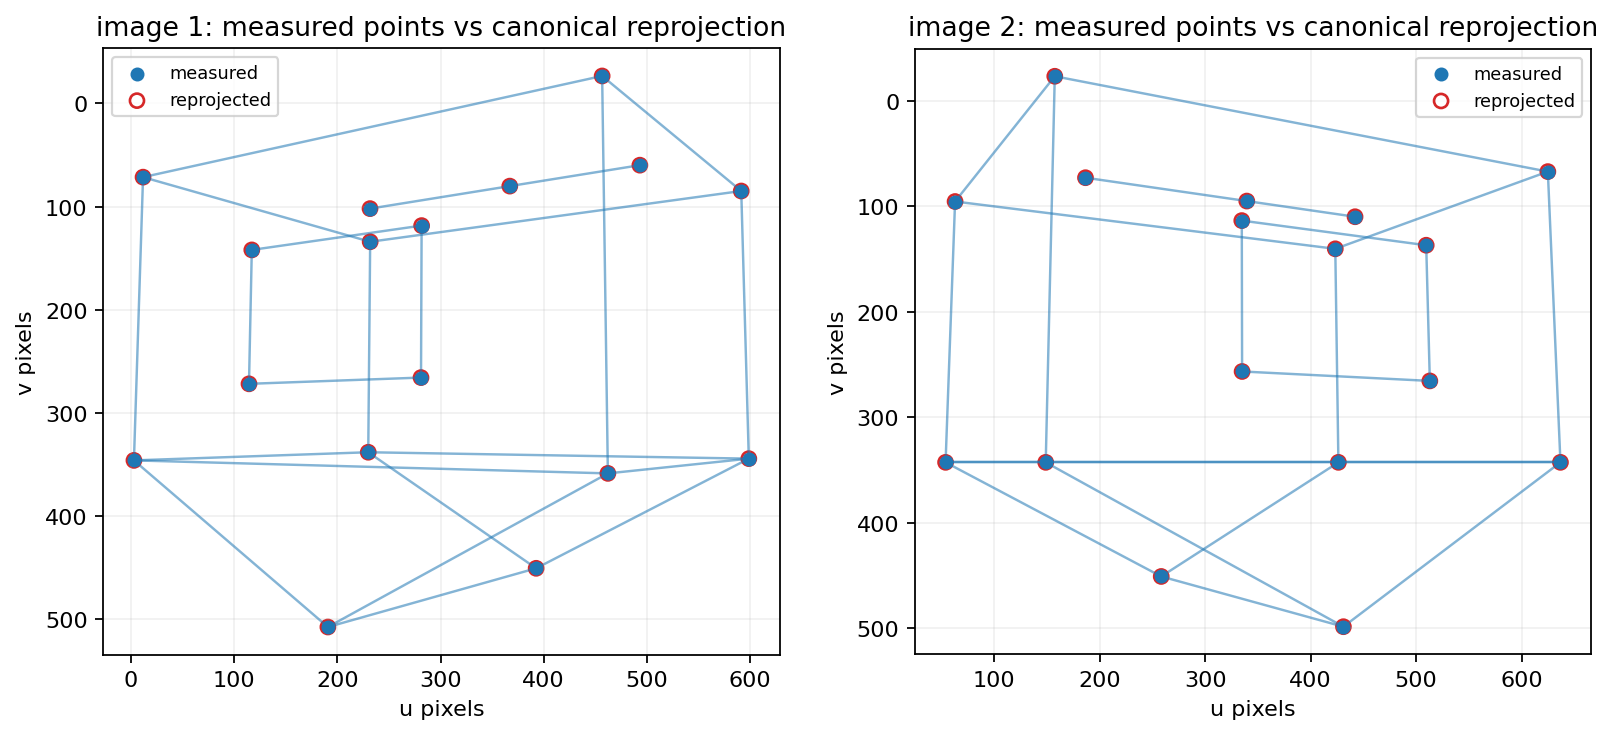

{'canonical_reprojection_max_px': 1.2517206079572008e-10,
 'eight_point_sampson_max': 8.173176472886726e-21}

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, original, recovered, title in [
    (axes[0], image_1, reprojected_1, "image 1"),
    (axes[1], image_2, reprojected_2, "image 2"),
]:
    draw_image_edges(ax, original, scene_edges, color="#1f77b4", label="measured")
    ax.scatter(recovered[:, 0], recovered[:, 1], s=40, facecolors="none", edgecolors="#d62728", linewidths=1.2, label="reprojected")
    for measured, reproj in zip(original, recovered):
        delta = reproj - measured
        if np.linalg.norm(delta) > 1e-8:
            ax.arrow(measured[0], measured[1], delta[0], delta[1], color="#d62728", alpha=0.6, head_width=1.5, length_includes_head=True)
    ax.set_title(f"{title}: measured points vs canonical reprojection")
    ax.set_xlabel("u pixels")
    ax.set_ylabel("v pixels")
    ax.legend(loc="best", fontsize=8)
reprojection_path = save_matplotlib(fig, TOPIC, "figures", "canonical-reprojection-invariance-overlay.png")
plt.close(fig)
artifact_paths.append(reprojection_path)
display_artifact(reprojection_path, width=900)
{
    "canonical_reprojection_max_px": check_data["canonical_reprojection_max_px"],
    "eight_point_sampson_max": check_data["eight_point_sampson_max"],
}

## Projective Ambiguity: Same Images, Different 3D Coordinates

For any nonsingular `4 x 4` matrix $H$, the replacement $X_i \mapsto H X_i$ and $P \mapsto P H^{-1}$ leaves $P_i X_i$ unchanged up to homogeneous scale. The interactive artifact compares the Euclidean scene with a deliberately non-affine projective warp. Parallelism and angles change in 3D, but the two images do not.

In [8]:
projective_warp = np.array(
    [
        [1.05, 0.20, -0.04, 0.35],
        [-0.10, 0.92, 0.08, -0.20],
        [0.04, -0.06, 1.12, 0.18],
        [0.22, -0.15, 0.06, 1.00],
    ],
    dtype=float,
)
warped_points = apply_homography_3d(projective_warp, scene_points)
P1_warped = P1 @ np.linalg.inv(projective_warp)
P2_warped = P2 @ np.linalg.inv(projective_warp)
warp_reprojected_1 = project_points(P1_warped, warped_points)
warp_reprojected_2 = project_points(P2_warped, warped_points)
projective_warp_reprojection_max = float(
    max(np.max(np.linalg.norm(warp_reprojected_1 - image_1, axis=1)), np.max(np.linalg.norm(warp_reprojected_2 - image_2, axis=1)))
)

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("Euclidean coordinates", "After 3D projective warp"),
)

def add_plotly_structure(fig, points, edges, *, row, col, name, color):
    fig.add_trace(go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2], mode="markers", marker=dict(size=4, color=color), name=f"{name} points"), row=row, col=col)
    xs, ys, zs = [], [], []
    for i, j in edges:
        xs.extend([points[i, 0], points[j, 0], None])
        ys.extend([points[i, 1], points[j, 1], None])
        zs.extend([points[i, 2], points[j, 2], None])
    fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode="lines", line=dict(color=color, width=4), name=f"{name} edges"), row=row, col=col)

add_plotly_structure(fig, scene_points, scene_edges, row=1, col=1, name="Euclidean", color="#1f77b4")
add_plotly_structure(fig, warped_points, scene_edges, row=1, col=2, name="Projective", color="#d62728")
for col, centers, label in [
    (1, np.vstack([camera_center(P1)[:3], camera_center(P2)[:3]]), "Euclidean cameras"),
    (2, np.vstack([camera_center(P1_warped)[:3], camera_center(P2_warped)[:3]]), "Warped cameras"),
]:
    fig.add_trace(go.Scatter3d(x=centers[:, 0], y=centers[:, 1], z=centers[:, 2], mode="markers+text", marker=dict(size=7, color="#111111"), text=["C1", "C2"], textposition="top center", name=label), row=1, col=col)
fig.update_layout(
    title="The same image measurements admit projectively different 3D scenes",
    height=620,
    width=1100,
    margin=dict(l=0, r=0, b=0, t=60),
    showlegend=True,
)
fig.update_scenes(aspectmode="data")
ambiguity_path = save_plotly_html(fig, TOPIC, "interactive", "projective-ambiguity-same-images.html")
artifact_paths.append(ambiguity_path)
check_data["projective_warp_reprojection_max_px"] = projective_warp_reprojection_max
display_artifact(ambiguity_path, width=920, height=620)
projective_warp_reprojection_max

.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


4.2780337774645343e-13

## Stratified Reconstruction: Projective To Affine To Metric

The stratified path adds information in stages. Locating $\pi_\infty$ fixes the affine stratum: parallel scene directions become meaningful again, but right angles need not be correct. Identifying the absolute conic, or equivalently using its image $\omega$, supplies the metric stratum: angles and length ratios become similarity invariants.

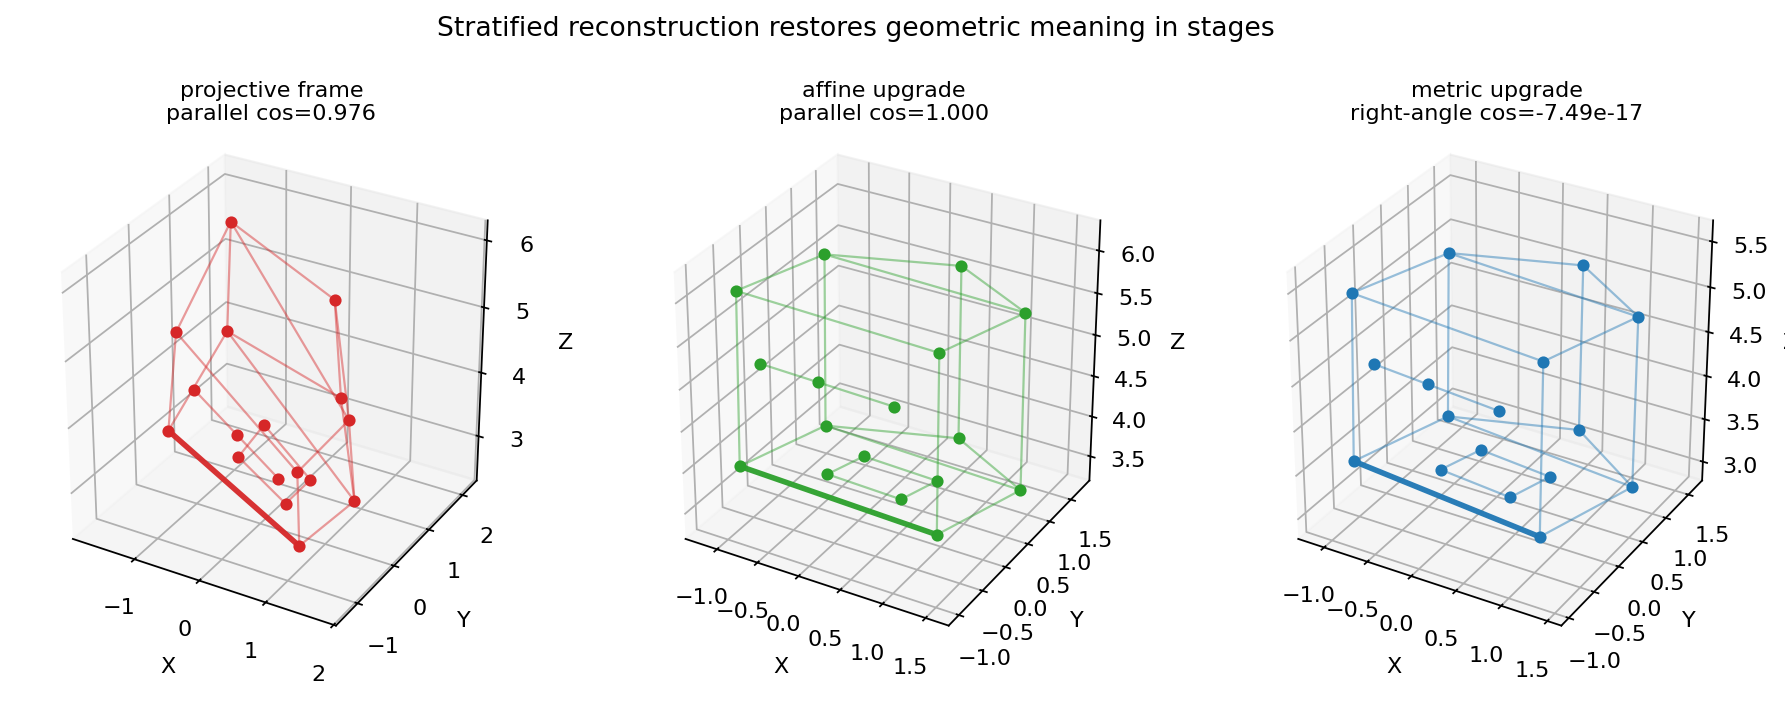

{'affine_plane_mapping_error': 2.7779122689378e-17,
 'parallel_cosine_affine_frame': 0.9999999999999999,
 'right_angle_cosine_metric_frame': -7.486157857638004e-17,
 'metric_cholesky_identity_error': 2.203440269029024e-16,
 'sympy_plane_identity_is_zero': True}

In [9]:
plane_at_infinity_in_projective_frame = np.linalg.inv(projective_warp).T @ np.array([0.0, 0.0, 0.0, 1.0])
H_to_affine = np.vstack([np.column_stack([np.eye(3), np.zeros(3)]), plane_at_infinity_in_projective_frame])
plane_check = np.linalg.inv(H_to_affine).T @ plane_at_infinity_in_projective_frame
plane_check = plane_check / plane_check[-1]
affine_points = dehomogenize((H_to_affine @ (projective_warp @ homogenize(scene_points).T)).T)
P1_affine = P1_warped @ np.linalg.inv(H_to_affine)
omega_iac = np.linalg.inv(K @ K.T)
M_affine = P1_affine[:, :3]
metric_shape_matrix = np.linalg.inv(M_affine.T @ omega_iac @ M_affine)
A_cholesky = np.linalg.cholesky(metric_shape_matrix)
H_to_metric = np.eye(4)
H_to_metric[:3, :3] = np.linalg.inv(A_cholesky)
metric_points = dehomogenize((H_to_metric @ homogenize(affine_points).T).T)

parallel_projective = direction_cosine(warped_points, (0, 1), (3, 2))
parallel_affine = direction_cosine(affine_points, (0, 1), (3, 2))
right_angle_affine = direction_cosine(affine_points, (0, 1), (0, 3))
right_angle_metric = direction_cosine(metric_points, (0, 1), (0, 3))
cholesky_identity_error = float(np.linalg.norm(A_cholesky @ A_cholesky.T - metric_shape_matrix))
plane_mapping_error = float(np.linalg.norm(plane_check - np.array([0.0, 0.0, 0.0, 1.0])))

fig = plt.figure(figsize=(14, 4.8))
axes = [fig.add_subplot(1, 3, i + 1, projection="3d") for i in range(3)]
for ax, pts, color, title in [
    (axes[0], warped_points, "#d62728", f"projective frame/nparallel cos={parallel_projective:.3f}"),
    (axes[1], affine_points, "#2ca02c", f"affine upgrade/nparallel cos={parallel_affine:.3f}"),
    (axes[2], metric_points, "#1f77b4", f"metric upgrade/nright-angle cos={right_angle_metric:.2e}"),
]:
    draw_structure_3d(ax, pts, scene_edges, color=color, title=title)
    set_equal_3d(ax, [pts])
fig.suptitle("Stratified reconstruction restores geometric meaning in stages", y=0.98)
stratified_path = save_matplotlib(fig, TOPIC, "figures", "stratified-affine-metric-upgrade.png")
plt.close(fig)
artifact_paths.append(stratified_path)

pi1, pi2, pi3, pi4 = sp.symbols("pi1 pi2 pi3 pi4", nonzero=True)
H_symbolic = sp.Matrix([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [pi1, pi2, pi3, pi4]])
pi_symbolic = sp.Matrix([pi1, pi2, pi3, pi4])
symbolic_plane_identity = sp.simplify(H_symbolic.inv().T * pi_symbolic - sp.Matrix([0, 0, 0, 1]))

check_data.update(
    {
        "affine_plane_mapping_error": plane_mapping_error,
        "parallel_cosine_projective_frame": float(parallel_projective),
        "parallel_cosine_affine_frame": float(parallel_affine),
        "right_angle_cosine_affine_frame": float(right_angle_affine),
        "right_angle_cosine_metric_frame": float(right_angle_metric),
        "metric_cholesky_identity_error": cholesky_identity_error,
        "sympy_plane_identity_is_zero": bool(symbolic_plane_identity == sp.zeros(4, 1)),
    }
)
display_artifact(stratified_path, width=920)
{key: check_data[key] for key in ["affine_plane_mapping_error", "parallel_cosine_affine_frame", "right_angle_cosine_metric_frame", "metric_cholesky_identity_error", "sympy_plane_identity_is_zero"]}

## Direct Metric Upgrade From Ground Control

The direct route uses known world points to compute the missing `4 x 4` homography. Five non-coplanar control points are enough in exact arithmetic because each 3D correspondence contributes three independent equations. Here five controls align the projective reconstruction with the Euclidean scene, and the remaining points are used as a held-out check.

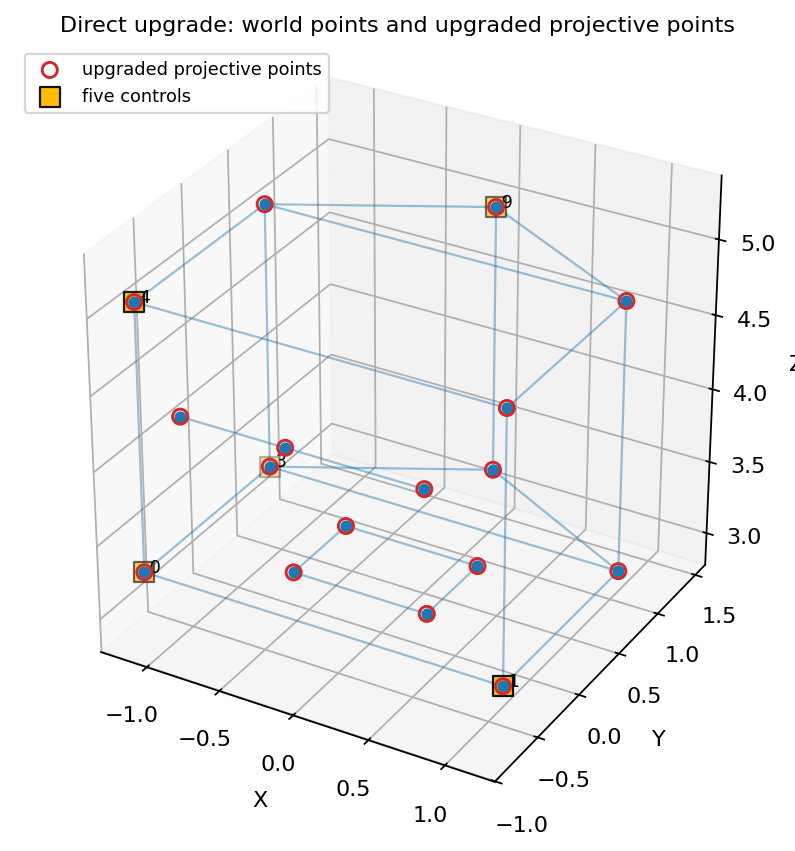

[ground-control-direct-upgrade-residuals.csv](Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-10/tables/ground-control-direct-upgrade-residuals.csv)

{'ground_control_control_rmse': 2.436401144110388e-13,
 'ground_control_all_point_rmse': 4.1825241201984744e-13,
 'ground_control_max_heldout_error': 8.556827370637976e-13}

In [10]:
control_indices = np.array([0, 1, 3, 4, 9])
H_ground_control = estimate_projective_homography_3d(projective_points[control_indices], scene_points[control_indices])
ground_control_points = apply_homography_3d(H_ground_control, projective_points)
control_errors = np.linalg.norm(ground_control_points[control_indices] - scene_points[control_indices], axis=1)
all_ground_errors = np.linalg.norm(ground_control_points - scene_points, axis=1)
residual_rows = [
    {
        "point_index": int(i),
        "is_control": bool(i in set(control_indices.tolist())),
        "euclidean_x": float(scene_points[i, 0]),
        "euclidean_y": float(scene_points[i, 1]),
        "euclidean_z": float(scene_points[i, 2]),
        "upgrade_error": float(all_ground_errors[i]),
    }
    for i in range(len(scene_points))
]
residual_table_path = save_csv(residual_rows, TOPIC, "tables", "ground-control-direct-upgrade-residuals.csv")
artifact_paths.append(residual_table_path)

fig = plt.figure(figsize=(9.5, 6.2))
ax = fig.add_subplot(111, projection="3d")
draw_structure_3d(ax, scene_points, scene_edges, color="#1f77b4", title="Direct upgrade: world points and upgraded projective points", highlight=False)
ax.scatter(ground_control_points[:, 0], ground_control_points[:, 1], ground_control_points[:, 2], s=46, facecolors="none", edgecolors="#d62728", linewidths=1.3, depthshade=False, label="upgraded projective points")
ax.scatter(scene_points[control_indices, 0], scene_points[control_indices, 1], scene_points[control_indices, 2], s=80, marker="s", color="#ffbf00", edgecolors="#111111", label="five controls")
for i in control_indices:
    ax.text(scene_points[i, 0], scene_points[i, 1], scene_points[i, 2], f" {i}", fontsize=8)
set_equal_3d(ax, [scene_points, ground_control_points])
ax.legend(loc="upper left", fontsize=8)
ground_control_path = save_matplotlib(fig, TOPIC, "figures", "ground-control-direct-upgrade.png")
plt.close(fig)
artifact_paths.append(ground_control_path)

check_data.update(
    {
        "ground_control_count": int(len(control_indices)),
        "ground_control_control_rmse": float(np.sqrt(np.mean(control_errors**2))),
        "ground_control_all_point_rmse": float(np.sqrt(np.mean(all_ground_errors**2))),
        "ground_control_max_heldout_error": float(np.max(np.delete(all_ground_errors, control_indices))),
    }
)
display_artifact(ground_control_path, width=840)
display_artifact(residual_table_path)
{key: check_data[key] for key in ["ground_control_control_rmse", "ground_control_all_point_rmse", "ground_control_max_heldout_error"]}

## Applied Lab

Change one of the information sources and predict which checks should fail.

- Replace the projective warp by an affine warp whose last row is `(0, 0, 0, 1)`. The projective and affine parallel checks should become almost identical because the plane at infinity was never moved.
- Remove one ground-control point. The `4 x 4` direct upgrade becomes under-constrained and the held-out error should no longer certify a unique homography.
- Perturb image correspondences before estimating `F`. Reprojection residuals and ground-control errors should become nonzero, motivating the statistically careful algorithms in the following chapters.

## Final Sanity Checks

The final cell records both artifact integrity and chapter-specific geometric invariants. The tolerances are tight because the data are synthetic and noise-free; real image data would need robust estimation and uncertainty-aware thresholds.

In [11]:
invariant_path = save_json(check_data, TOPIC, "checks", "reconstruction-invariants.json")
artifact_paths.append(invariant_path)

assert_artifacts(artifact_paths, min_bytes=500)
assert check_data["point_count"] >= 8
assert check_data["eight_point_rank"] == 2
assert check_data["eight_point_sampson_max"] < 1e-12
assert check_data["opencv_sampson_max"] < 1e-8
assert check_data["canonical_reprojection_max_px"] < 1e-7
assert check_data["regular_triangulation_rank"] == 3
assert check_data["baseline_triangulation_rank"] == 2
assert check_data["theorem_graph_is_dag"]
assert check_data["projective_warp_reprojection_max_px"] < 1e-8
assert check_data["affine_plane_mapping_error"] < 1e-10
assert abs(check_data["parallel_cosine_affine_frame"] - 1.0) < 1e-10
assert abs(check_data["right_angle_cosine_metric_frame"]) < 1e-10
assert check_data["metric_cholesky_identity_error"] < 1e-10
assert check_data["sympy_plane_identity_is_zero"]
assert check_data["ground_control_count"] >= 5
assert check_data["ground_control_all_point_rmse"] < 1e-8

final_sanity = {
    "artifact_count": len(artifact_paths),
    "artifacts": [str(path.relative_to(BOOK_ROOT)) for path in artifact_paths],
    "key_checks": {key: check_data[key] for key in [
        "eight_point_sampson_max",
        "canonical_reprojection_max_px",
        "projective_warp_reprojection_max_px",
        "affine_plane_mapping_error",
        "right_angle_cosine_metric_frame",
        "ground_control_all_point_rmse",
    ]},
}
display_artifact(invariant_path)
final_sanity

`artifacts/chapter-10/checks/reconstruction-invariants.json`

{'artifact_count': 8,
 'artifacts': ['artifacts//chapter-10//figures//triangulation-epipolar-rays.png',
  'artifacts//chapter-10//figures//projective-reconstruction-theorem-dependency.png',
  'artifacts//chapter-10//figures//canonical-reprojection-invariance-overlay.png',
  'artifacts//chapter-10//interactive//projective-ambiguity-same-images.html',
  'artifacts//chapter-10//figures//stratified-affine-metric-upgrade.png',
  'artifacts//chapter-10//tables//ground-control-direct-upgrade-residuals.csv',
  'artifacts//chapter-10//figures//ground-control-direct-upgrade.png',
  'artifacts//chapter-10//checks//reconstruction-invariants.json'],
 'key_checks': {'eight_point_sampson_max': 8.173176472886726e-21,
  'canonical_reprojection_max_px': 1.2517206079572008e-10,
  'projective_warp_reprojection_max_px': 4.2780337774645343e-13,
  'affine_plane_mapping_error': 2.7779122689378e-17,
  'right_angle_cosine_metric_frame': -7.486157857638004e-17,
  'ground_control_all_point_rmse': 4.18252412019847

## Takeaways

- Two-view correspondences can recover cameras and structure only up to a 3D projective transformation unless extra information is supplied.
- Triangulation is geometrically an intersection of rays, with the baseline/epipole case as the visible failure mode.
- The affine upgrade is exactly the act of locating the plane at infinity; it restores parallel constructions but not angles.
- The metric upgrade adds the absolute conic or its image, restoring the similarity class of the Euclidean scene.
- Ground control points bypass the stratified route by directly estimating the missing 3D homography.